[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_07/MFM_ch7_seminar/MFM_ch7_seminar.ipynb)

# Modelling Financial Markets — Seminar 7: Value-at-Risk and Expected Shortfall

*Seminar notebook. Daniel Traian Pele, Antoaneta Amza, Bucharest University of Economic Studies.*

- **[Solved]** problems contain the full solution; **[Proposed]** problems are solved by you.
- Part A: derivations (A1–A8); Part B: estimation and inference (B1–B7); Part C: AI critique (C1) and open projects (C2, C3).
- The seminar comes before Lecture 7; the slides open with a short primer (VaR and ES, coherence, historical and filtered simulation, horizons).
- **In class**: A1–A4, B1, B2, B3, C1. **After the lecture**: B4 (extreme value theory), A5 and B5 (risk contributions); the other sections are optional extensions.

> Quantlet `MFM_ch7_seminar`: student version of the Seminar 7 notebook. Solved exercises (A1, A2, A2 Extended, A3, A5, A5 Extended, B1, B1 Extended, B4, B4 Extended) are shown with code and output; the proposed exercises (A4, A4 Extended, A6, A7, A8, B2, B3, B3 Extended, B5, B5 Extended, B6, B7, C1) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# On Colab, install arch first: !pip install arch
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, signal
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [ ]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Brand colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'
METHOD_COL = {'HS': MainBlue, 'Normal': Orange, 'Student-t': Forest, 'Cornish-Fisher': Purple, 'EVT (GPD)': IDAred}

HERE = '.'
SEED = 42
ORDER = ['sp500', 'bet', 'btc', 'eurron', 'gold']
METHODS = ['HS', 'Normal', 'Student-t', 'Cornish-Fisher', 'EVT (GPD)']
B_BOOT = 2000


def save_fig(name):
    """Save the figure as a transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
# with SAVE_TO_DRIVE = True (cell at the top), tables and charts are kept in OUT_DIR; otherwise in a temporary folder
KEEP = bool(globals().get('SAVE_TO_DRIVE', False))
HERE = globals().get('OUT_DIR', '.') if KEEP else tempfile.gettempdir()


def save_fig(name):
    """Show the figure; save it as PNG in OUT_DIR when SAVE_TO_DRIVE is on."""
    if KEEP:
        plt.savefig(os.path.join(HERE, name + '.png'), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026: S&P 500, BET, Bitcoin, EUR/RON (BNR reference rate), gold (USD per troy ounce).
- Equity indices: weekdays only; holiday records (unchanged close, zero volume) removed, genuine unchanged closes kept; gold: weekdays only; Bitcoin: 7 days a week.
- Daily log return in %, $r_t = 100(\ln P_t - \ln P_{t-1})$; log loss $L = -r$; VaR and ES are positive numbers. In money, a log loss $L$ is $V(1 - e^{-L/100})$.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# use the local copy of the course data when the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, type, start date)
MARKETS = {
    'sp500':  ('GSPC.INDX',    'S&P 500',                  'index',  '2000-01-01'),
    'bet':    ('BET',          'BET',                      'index',  '2000-01-01'),
    'btc':    ('BTC-USD.CC',   'Bitcoin',                  'crypto', '2014-09-17'),
    'eurron': ('REF:EUR',      'EUR/RON (reference rate)', 'fx',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX', 'Gold (XAU/USD)',           'fx',     '2000-01-01'),
}
# portfolio assets (prices aligned on common days)
ASSETS = {
    'SPY': ('SPY.US', 'adjusted_close'), 'TLT': ('TLT.US', 'adjusted_close'), 'GLD': ('GLD.US', 'adjusted_close'),
    'BTC': ('BTC-USD.CC', 'close'),
    'TLV': ('TLV.RO', 'adjusted_close'), 'SNP': ('SNP.RO', 'adjusted_close'), 'BRD': ('BRD.RO', 'adjusted_close'),
    'TGN': ('TGN.RO', 'adjusted_close'), 'SNG': ('SNG.RO', 'adjusted_close'), 'SNN': ('SNN.RO', 'adjusted_close'),
    'EL': ('EL.RO', 'adjusted_close'), 'FP': ('FP.RO', 'adjusted_close'), 'TEL': ('TEL.RO', 'adjusted_close'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Read the daily price series of one symbol (local copy of the course data, else from GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (annual BNR XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Daily price, cleaned according to the chapter conventions."""
    symbol, _, kind, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    d = read_market(symbol).loc[start:end]
    d = d[d['close'] > 0].dropna(subset=['close'])
    if kind != 'crypto':
        d = d[d.index.dayofweek < 5]          # no weekend quotes
    s = d['close']
    if kind == 'index' and 'volume' in d:
        # drop holidays filled with the previous price: unchanged close and zero/missing volume
        s = s[~((s.diff() == 0) & (d['volume'].fillna(0) <= 0))]
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Log returns on the series' own calendar."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


def periods_per_year(r):
    """Actual frequency: average number of observations per calendar year."""
    return len(r) / ((r.index[-1] - r.index[0]).days / 365.25)


def asset_price(key, end=END):
    symbol, col = ASSETS[key]
    s = read_market(symbol)[col].loc[:end]
    s = s[s > 0].dropna()
    if key != 'BTC':
        s = s[s.index.dayofweek < 5]
    return s.rename(key)


def joint_returns(keys, start=None, end=END):
    """Log returns for several assets: align the PRICES on common days first, then compute returns."""
    p = pd.concat([asset_price(k, end) for k in keys], axis=1, join='inner').dropna()
    if start:
        p = p.loc[start:]
    return np.log(p).diff().dropna()


# daily log returns in %, loss L = -r
rets = {k: 100 * log_returns(k) for k in MARKETS}
loss = {k: -v for k, v in rets.items()}
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

## Risk measures

- VaR and ES by four methods: historical, Normal distribution, Student-$t$, Cornish–Fisher (`hs_var_es`, `normal_var_es`, `t_var_es`, `cf_var_es`).
- Historical convention: VaR = interpolated empirical $(1-\alpha)$-quantile of the loss; ES = mean of the losses at or above it (about $n\alpha$ losses; the exact plug-in of the integral would weight the boundary loss by $n\alpha - \lfloor n\alpha \rfloor$).
- Peaks over threshold: GPD fit, GPD VaR and ES, standard errors, mean excess (`gpd_fit`, `gpd_var_es`, `gpd_se`, `mean_excess`).
- AR(1)-GARCH(1,1) filtering, filtered historical simulation and conditional EVT (`garch_filter`, `garch_next`, `fhs_mc`, `rolling_conditional`).

In [ ]:
def hs_var_es(L, alpha):
    """Historical simulation: VaR alpha = empirical (1 - alpha)-quantile of the loss; ES = mean of the losses beyond it."""
    L = np.asarray(L)
    v = np.quantile(L, 1 - alpha)
    return v, L[L >= v].mean()


def normal_var_es(L, alpha):
    """Distributia Normala: VaR = -mu_X + sigma z_{1-alpha}, ES = -mu_X + sigma phi(z_alpha)/alpha (mu_L = -mu_X)."""
    mu, s = np.mean(L), np.std(L, ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return mu + s * z, mu + s * stats.norm.pdf(z) / alpha


def t_fit(L):
    """Student-t with location and scale, fitted by maximum likelihood."""
    return stats.t.fit(np.asarray(L))


def t_var_es(L, alpha, params=None):
    """Student-t on losses: VaR = m + s t_{1-alpha}, ES = m + s g(t_alpha)/alpha (nu + t_alpha^2)/(nu - 1)."""
    nu, m, s = params if params is not None else t_fit(L)
    q = stats.t.ppf(1 - alpha, nu)
    return m + s * q, m + s * stats.t.pdf(q, nu) / alpha * (nu + q ** 2) / (nu - 1)


def cf_quantile(z, S, K):
    """Standardised Cornish-Fisher quantile: z = Normal quantile, S = skewness, K = excess kurtosis."""
    return z + (z ** 2 - 1) * S / 6 + (z ** 3 - 3 * z) * K / 24 - (2 * z ** 3 - 5 * z) * S ** 2 / 36


def cf_var_es(L, alpha):
    """Cornish-Fisher on returns X = -L: VaR = -(mu_X + sigma z~_alpha); ES = mean of VaR_u for u in (0, alpha)."""
    X = -np.asarray(L)
    mu, s = X.mean(), X.std(ddof=1)
    S, K = stats.skew(X), stats.kurtosis(X)
    var = -(mu + s * cf_quantile(stats.norm.ppf(alpha), S, K))
    es = -integrate.quad(lambda u: mu + s * cf_quantile(stats.norm.ppf(u), S, K), 0, alpha, limit=200)[0] / alpha
    return var, es


def gpd_fit(L, tail=0.05):
    """POT: the threshold u leaves the share tail of the losses above it; GPD fitted by maximum likelihood to the excesses."""
    L = np.asarray(L)
    u = np.quantile(L, 1 - tail)
    ex = L[L > u] - u
    xi, _, beta = stats.genpareto.fit(ex, floc=0)
    return dict(u=u, xi=xi, beta=beta, nu=len(ex), n=len(L))


def gpd_var_es(fit, alpha):
    """VaR and ES at tail probability alpha from the GPD tail (Smith-type estimator)."""
    u, xi, beta, nu, n = fit['u'], fit['xi'], fit['beta'], fit['nu'], fit['n']
    var = u + beta / xi * (((n / nu) * alpha) ** (-xi) - 1)
    return var, var / (1 - xi) + (beta - xi * u) / (1 - xi)


def gpd_se(fit):
    """Asymptotic standard errors of the GPD maximum likelihood estimates (xi > -1/2)."""
    xi, beta, nu = fit['xi'], fit['beta'], fit['nu']
    return np.sqrt((1 + xi) ** 2 / nu), np.sqrt(2 * beta ** 2 * (1 + xi) / nu)


def mean_excess(L, us):
    """Mean excess function e(u) = E[L - u | L > u] on a grid of thresholds."""
    L = np.asarray(L)
    return np.array([(L[L > u] - u).mean() for u in us]), np.array([(L > u).sum() for u in us])


def garch_backcast(x):
    """Starting value of the variance (as in arch): EWMA mean (0.94) of the first 75 squared residuals
    of an AR(1) fitted by OLS, computed ONLY on the estimation sample x."""
    x = np.asarray(x, float)
    X = np.column_stack([np.ones(len(x) - 1), x[:-1]])
    e = x[1:] - X @ np.linalg.lstsq(X, x[1:], rcond=None)[0]
    tau = min(75, len(e))
    w = 0.94 ** np.arange(tau)
    return float((w / w.sum()) @ e[:tau] ** 2)


def garch_filter(r, params=None, last_obs=None):
    """AR(1)-GARCH(1,1) by Normal QML (Chapter 5); r in %.
    Parameters are estimated on the data before last_obs; the filter is causal: mu_t and sigma_t use
    only r_1..r_{t-1}, and the starting variance comes only from the estimation sample.
    Returns the parameters and the series mu_t, sigma_t for the whole sample."""
    if params is None:
        am = arch_model(r, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal', rescale=False)
        params = am.fit(disp='off', last_obs=last_obs).params
    est = r if last_obs is None else r.loc[r.index < pd.Timestamp(last_obs)]
    c, phi, om, al, be = params.values[:5]
    x = np.asarray(r, float)
    mu = np.full(len(x), np.nan)
    mu[1:] = c + phi * x[:-1]
    e = x - mu
    u = np.empty(len(x) - 1)
    u[0] = om + (al + be) * garch_backcast(np.asarray(est, float))
    u[1:] = om + al * e[1:-1] ** 2
    s2 = np.full(len(x), np.nan)
    s2[1:] = signal.lfilter([1.0], [1.0, -be], u)
    return params, pd.Series(mu, index=r.index), pd.Series(np.sqrt(s2), index=r.index)


def garch_next(r, params):
    """Conditional mean and volatility for the day after the last observation."""
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    e = r.iloc[-1] - mu.iloc[-1]
    return c + phi * r.iloc[-1], np.sqrt(om + al * e ** 2 + be * sig.iloc[-1] ** 2)


def fhs_mc(r, params, z, h, n_paths=100_000, seed=42):
    """FHS Monte Carlo: h-day AR(1)-GARCH(1,1) paths with resampled standardised residuals.
    Returns the cumulative h-day losses (in %, log returns)."""
    rng = np.random.default_rng(seed)
    c, phi, om, al, be = params.values[:5]
    _, mu, sig = garch_filter(r, params)
    r_prev = np.full(n_paths, r.iloc[-1])
    e_prev = np.full(n_paths, r.iloc[-1] - mu.iloc[-1])
    s2_prev = np.full(n_paths, sig.iloc[-1] ** 2)
    tot = np.zeros(n_paths)
    for _ in range(h):
        s2 = om + al * e_prev ** 2 + be * s2_prev
        e = np.sqrt(s2) * rng.choice(z, n_paths)
        r_new = c + phi * r_prev + e
        tot += r_new
        r_prev, e_prev, s2_prev = r_new, e, s2
    return -tot


def rolling_conditional(r, first_year, window_hs=500, alpha=0.01, tail_evt=0.10):
    """Day-by-day conditional VaR/ES: AR(1)-GARCH parameters re-estimated at the start of every year
    on all earlier data; FHS and conditional EVT use the earlier standardised residuals.
    For comparison: HS on a rolling window of window_hs days. No look-ahead bias."""
    out = []
    L = -r
    for y in range(first_year, r.index[-1].year + 1):
        est = r.loc[:f'{y - 1}-12-31']
        params, mu, sig = garch_filter(r, last_obs=f'{y}-01-01')
        z = ((est - mu.loc[est.index]) / sig.loc[est.index]).dropna()
        nz = -z.values
        fz = gpd_fit(nz, tail_evt)
        q_fhs, q_evt_v = np.quantile(nz, 1 - alpha), gpd_var_es(fz, alpha)[0]
        es_fhs = nz[nz >= q_fhs].mean()
        es_evt = gpd_var_es(fz, alpha)[1]
        days = r.loc[f'{y}-01-01':f'{y}-12-31'].index
        for d in days:
            i = r.index.get_loc(d)
            past = L.iloc[max(0, i - window_hs):i]
            out.append((d, L.loc[d], -mu.loc[d] + sig.loc[d] * q_fhs, -mu.loc[d] + sig.loc[d] * es_fhs,
                        -mu.loc[d] + sig.loc[d] * q_evt_v, -mu.loc[d] + sig.loc[d] * es_evt,
                        -mu.loc[d] + sig.loc[d] * stats.norm.ppf(1 - alpha), np.quantile(past, 1 - alpha), sig.loc[d]))
    return pd.DataFrame(out, columns=['date', 'loss', 'fhs_var', 'fhs_es', 'cevt_var', 'cevt_es', 'ngarch_var',
                                      'hs_var', 'sigma']).set_index('date')

## Seminar functions

- Discrete VaR/ES, bootstrap intervals and the tables used in Part B.

In [ ]:
B_BOOT = 2000
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'SNG', 'SNN', 'EL', 'TEL']
C_START = '2016-09-19'


def discrete_var_es(values, probs, alpha):
    """VaR and ES at tail probability alpha for a discrete loss L = -X (Acerbi-Tasche formula).
    VaR_alpha = -inf{x : P(X <= x) > alpha}; ES_alpha = (E[L 1{L > VaR}] + VaR (alpha - P(L > VaR))) / alpha."""
    order = np.argsort(values)
    x, p = np.asarray(values)[order], np.asarray(probs)[order]
    cdf = np.cumsum(p)
    var = x[np.searchsorted(cdf, 1 - alpha - 1e-12)]
    tail = x > var
    es = ((x[tail] * p[tail]).sum() + var * (alpha - p[tail].sum())) / alpha
    return var, es


def all_methods(L, alpha):
    """VaR and ES at level alpha for all unconditional methods."""
    f = gpd_fit(L, 0.05)
    return {'HS': hs_var_es(L, alpha), 'Normal': normal_var_es(L, alpha), 'Student-t': t_var_es(L, alpha),
            'Cornish-Fisher': cf_var_es(L, alpha), 'EVT (GPD)': gpd_var_es(f, alpha)}


def summary_table():
    """Descriptive statistics and VaR/ES (1%, 2.5%) by method for the five series."""
    rows = {}
    for k in ORDER:
        L = loss[k]
        nu, m, s = t_fit(L)
        f = gpd_fit(L, 0.05)
        row = dict(N=len(L), start=str(L.index[0].date()), mean=L.mean(), sd=L.std(), skew=stats.skew(L),
                   kurt=stats.kurtosis(L), max=L.max(), max_date=str(L.idxmax().date()), t_nu=nu, t_loc=m, t_scale=s,
                   gpd_u=f['u'], gpd_xi=f['xi'], gpd_beta=f['beta'], gpd_nu=f['nu'],
                   gpd_xi_se=gpd_se(f)[0], ppy=periods_per_year(L))
        for a, tag in [(0.01, '1%'), (0.025, '2.5%')]:
            for meth, (v, e) in all_methods(L, a).items():
                row[f'{meth}|VaR {tag}'] = v
                row[f'{meth}|ES {tag}'] = e
        rows[k] = row
    t = pd.DataFrame(rows).T
    t.to_csv(os.path.join(HERE, 'ch7_var_es_table.csv'))
    return t


def boot_ci(L, fun, B=B_BOOT, block=None, seed=SEED):
    """95% percentile bootstrap interval: i.i.d. (block=None) or moving blocks of length block."""
    rng = np.random.default_rng(seed)
    L = np.asarray(L)
    n = len(L)
    stats_ = np.empty(B)
    for b in range(B):
        if block is None:
            x = L[rng.integers(0, n, n)]
        else:
            starts = rng.integers(0, n - block + 1, int(np.ceil(n / block)))
            x = np.concatenate([L[s:s + block] for s in starts])[:n]
        stats_[b] = fun(x)
    return np.percentile(stats_, [2.5, 97.5]), stats_


# tables reused in B3 and B6
t = summary_table()
rolling_conditional(rets['btc'], 2017).to_csv(os.path.join(HERE, 'ch7_rolling_btc.csv'))

In [ ]:
from scipy import optimize, signal


def nw_lrv(x):
    """Long-run variance (Newey-West, Bartlett kernel, lag floor(4 (n/100)^(2/9)))."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    m = int(np.floor(4 * (n / 100) ** (2 / 9)))
    s = x @ x / n
    for j in range(1, m + 1):
        s += 2 * (1 - j / (m + 1)) * (x[j:] @ x[:-j]) / n
    return s, m


def var_es_se(L, a_var=0.01, a_es=0.025):
    """Historical VaR: avar = a(1-a)/f(q)^2 (Gaussian kernel density, Silverman's rule);
    historical ES (Chen, 2008): influence function VaR + (L - VaR)_+/a - ES, avar = Var((L - VaR)_+)/a^2.
    HAC version: long-run variance of the indicator and of (L - VaR)_+, respectively."""
    L = np.asarray(L, float)
    n = len(L)
    v = np.quantile(L, 1 - a_var)
    f = stats.gaussian_kde(L, bw_method='silverman')(v)[0]
    ind = (L > v).astype(float)
    se_v = np.sqrt(a_var * (1 - a_var) / n) / f
    se_v_hac = np.sqrt(nw_lrv(ind)[0] / n) / f
    v2, e2 = hs_var_es(L, a_es)
    ex = np.maximum(L - v2, 0)
    se_e = ex.std(ddof=1) / (a_es * np.sqrt(n))
    lrv, m = nw_lrv(ex)
    se_e_hac = np.sqrt(lrv / n) / a_es
    return dict(n=n, var1=v, f=f, se_var=se_v, se_var_hac=se_v_hac, es=e2, var_es=v2, se_es=se_e,
                se_es_hac=se_e_hac, lag=m, ntail=a_es * n)


def se_theory(sigma=1.2, n=500, nu=4, alpha=0.01):
    """Asymptotic SE of the historical VaR 1% under the Normal distribution and under a Student-t (same standard deviation)."""
    z = stats.norm.ppf(1 - alpha)
    f_n = stats.norm.pdf(z) / sigma
    s = sigma * np.sqrt((nu - 2) / nu)
    q = stats.t.ppf(1 - alpha, nu)
    f_t = stats.t.pdf(q, nu) / s
    c = np.sqrt(alpha * (1 - alpha) / n)
    return dict(se_normal=c / f_n, se_t=c / f_t, q_normal=sigma * z, q_t=s * q)


def ru_objective(L, v, alpha):
    return v + np.maximum(np.asarray(L) - v, 0).mean() / alpha


def ru_check(L, alpha=0.025):
    L = np.asarray(L, float)
    res = optimize.minimize_scalar(lambda v: ru_objective(L, v, alpha), bounds=(0, L.max()), method='bounded',
                                   options=dict(xatol=1e-8))
    v, e = hs_var_es(L, alpha)
    return dict(argmin=res.x, min=res.fun, var=v, es=e)


def min_es_portfolio(R, alpha=0.025):
    """Minimum ES on scenarios (Rockafellar & Uryasev, 2000): min v + 1/(alpha N) sum u_s,
    u_s >= -R_s w - v, u_s >= 0, sum w = 1, w >= 0 (no short sales)."""
    N, d = R.shape
    c = np.concatenate([np.zeros(d), [1.0], np.full(N, 1 / (alpha * N))])
    from scipy.sparse import csr_matrix, hstack as sh, identity
    A = sh([csr_matrix(-R), csr_matrix(-np.ones((N, 1))), -identity(N)]).tocsr()
    b = np.zeros(N)
    Aeq = np.concatenate([np.ones(d), [0.0], np.zeros(N)])[None, :]
    bounds = [(0, None)] * d + [(None, None)] + [(0, None)] * N
    out = optimize.linprog(c, A_ub=A, b_ub=b, A_eq=Aeq, b_eq=[1.0], bounds=bounds, method='highs')
    return out.x[:d], out.x[d], out.fun


def min_var_portfolio(R):
    S = np.cov(R.T)
    d = S.shape[0]
    res = optimize.minimize(lambda w: w @ S @ w, np.full(d, 1 / d), bounds=[(0, 1)] * d,
                            constraints=[dict(type='eq', fun=lambda w: w.sum() - 1)], method='SLSQP',
                            options=dict(ftol=1e-14, maxiter=500))
    return res.x


def drop_largest(L, alpha_var=0.01, alpha_es=0.025):
    """Sensitivity to a single observation: historical VaR 1% and ES 2.5% with and without the largest loss."""
    L = np.asarray(L, float)
    L2 = np.delete(L, np.argmax(L))
    return dict(max=L.max(), var=np.quantile(L, 1 - alpha_var), var_drop=np.quantile(L2, 1 - alpha_var),
                es=hs_var_es(L, alpha_es)[1], es_drop=hs_var_es(L2, alpha_es)[1])


def rearrangement(X, tol=1e-10, max_iter=1000):
    X = X.copy()
    for _ in range(max_iter):
        old = X.copy()
        for j in range(X.shape[1]):
            rest = X.sum(axis=1) - X[:, j]
            X[np.argsort(rest), j] = np.sort(X[:, j])[::-1]    # order opposite to the sum of the other columns
        if np.max(np.abs(X - old)) < tol:
            break
    return X


def worst_var_ra(Lcols, alpha=0.01, N=2000):
    """Worst-case VaR 1% of a sum with given marginals (Embrechts, Puccetti & Rueschendorf, 2013):
    discretise the tail of probability alpha of each marginal in N points (lower / upper) and rearrange;
    worst VaR ~ minimum of the row sums."""
    lo = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(N) / N) for x in Lcols])
    hi = np.column_stack([np.quantile(x, 1 - alpha + alpha * np.arange(1, N + 1) / N) for x in Lcols])
    return rearrangement(lo).sum(axis=1).min(), rearrangement(hi).sum(axis=1).min()


def aggregation(alpha=0.01):
    W = np.array([0.40, 0.30, 0.20, 0.10])
    lr = joint_returns(['SPY', 'TLT', 'GLD', 'BTC'], start='2014-09-18')
    R = 100 * (np.exp(lr) - 1)
    Lw = [-(R.values[:, i] * W[i]) for i in range(4)]
    como = sum(np.quantile(x, 1 - alpha) for x in Lw)
    hist = np.quantile(-(R.values @ W), 1 - alpha)
    lo, hi = worst_var_ra(Lw, alpha)
    # minimum ES (LP) and the minimum-variance portfolio, alpha = 2.5%
    w_es, v_es, es_min = min_es_portfolio(R.values, 0.025)
    w_mv = min_var_portfolio(R.values)
    es_mv = hs_var_es(-(R.values @ w_mv), 0.025)[1]
    es_ew = hs_var_es(-(R.values @ W), 0.025)[1]
    sd_es = np.std(R.values @ w_es, ddof=1)
    sd_mv = np.std(R.values @ w_mv, ddof=1)
    return dict(N=len(R), var_hist=hist, var_como=como, var_worst_lo=lo, var_worst_hi=hi,
                w_es=w_es, es_min=es_min, v_es=v_es, w_mv=w_mv, es_mv=es_mv, es_4030=es_ew, sd_es=sd_es, sd_mv=sd_mv)


def fhs_bootstrap(r, alpha=0.01, B=999, seed=SEED, level=0.90, return_draws=False):
    """Christoffersen & Goncalves (2005): AR(1)-GARCH(1,1) paths with resampled residuals;
    re-estimate the parameters on each path; sigma_{T+1} from the ORIGINAL data with the bootstrap parameters;
    quantile from the standardised residuals of the bootstrap path."""
    rng = np.random.default_rng(seed)
    params, mu, sig = garch_filter(r)
    z = ((r - mu) / sig).dropna().values
    m1, s1 = garch_next(r, params)
    var0 = -m1 + s1 * np.quantile(-z, 1 - alpha)
    c, phi, om, al, be = params.values[:5]
    n = len(r)
    out = np.empty(B)
    parts = np.empty((B, 2))
    for b in range(B):
        zz = rng.choice(z, n)
        rs = np.empty(n)
        s2 = om / (1 - al - be)
        rp, ep = r.iloc[0], 0.0
        for t in range(n):
            s2 = om + al * ep ** 2 + be * s2 if t > 0 else s2
            e = np.sqrt(s2) * zz[t]
            rs[t] = c + phi * rp + e
            rp, ep = rs[t], e
        rs = pd.Series(rs, index=r.index)
        pb, mub, sgb = garch_filter(rs)
        zb = ((rs - mub) / sgb).dropna().values
        mb, sb = garch_next(r, pb)                    # ORIGINAL history, bootstrap parameters
        qb = np.quantile(-zb, 1 - alpha)
        out[b] = -mb + sb * qb
        parts[b] = [sb, qb]
    lo, hi = np.quantile(out, [(1 - level) / 2, (1 + level) / 2])
    # decomposition: quantile uncertainty only (sigma fixed) vs sigma uncertainty only (quantile fixed)
    q0 = np.quantile(-z, 1 - alpha)
    only_q = np.quantile(-m1 + s1 * parts[:, 1], [(1 - level) / 2, (1 + level) / 2])
    only_s = np.quantile(-m1 + parts[:, 0] * q0, [(1 - level) / 2, (1 + level) / 2])
    res = dict(var=var0, lo=lo, hi=hi, sd=out.std(ddof=1), B=B, level=level, sigma=s1,
                sig_lo=np.quantile(parts[:, 0], (1 - level) / 2), sig_hi=np.quantile(parts[:, 0], (1 + level) / 2),
                q=q0, q_lo=np.quantile(parts[:, 1], (1 - level) / 2), q_hi=np.quantile(parts[:, 1], (1 + level) / 2),
                onlyq_lo=only_q[0], onlyq_hi=only_q[1], onlys_lo=only_s[0], onlys_hi=only_s[1])
    return (res, out) if return_draws else res


def caviar_path(beta, r, v0):
    """VaR_t = b0 + b1 VaR_{t-1} + b2 |r_{t-1}| (positive VaR; quantile q_t = -VaR_t)."""
    b0, b1, b2 = beta
    x = b0 + b2 * np.abs(np.asarray(r, float)[:-1])
    rest = signal.lfilter([1.0], [1.0, -b1], x, zi=[b1 * v0])[0]
    return np.concatenate([[v0], rest])


def pinball(r, q, alpha):
    """Mean pinball (tick) loss for the return quantile q: (alpha - 1{r < q})(r - q)."""
    return np.mean((alpha - (r < q)) * (r - q))


def caviar_fit(r, alpha=0.01, n_rand=10_000, n_best=10, seed=SEED):
    """Engle & Manganelli (2004): 10^4 starting vectors U(0,1), the best 10 refined by alternating simplex
    and quasi-Newton steps until convergence; starting VaR = empirical quantile of the first 300 observations."""
    r = np.asarray(r, float)
    v0 = -np.quantile(r[:300], alpha)
    obj = lambda b: pinball(r, -caviar_path(b, r, v0), alpha) if abs(b[1]) < 1 else 1e6  # noqa: E731
    rng = np.random.default_rng(seed)
    cand = rng.uniform(0, 1, (n_rand, 3))
    vals = np.array([obj(b) for b in cand])
    best = []
    for b in cand[np.argsort(vals)[:n_best]]:
        f_old = np.inf
        for _ in range(20):
            b = optimize.minimize(obj, b, method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-12, maxiter=4000)).x
            b = optimize.minimize(obj, b, method='BFGS').x
            f = obj(b)
            if f_old - f < 1e-12:
                break
            f_old = f
        best.append((obj(b), b))
    f, b = min(best, key=lambda x: x[0])
    return b, v0, f


def fig_caviar(v, fhs, name='sp500', title='S&P 500', start='2016-01-01'):
    d = fhs.loc[start:]
    fig, ax = plt.subplots(figsize=(10, 3.3))
    ax.bar(d.index, d['loss'].clip(lower=0), width=1.5, color=Teal, alpha=0.45, label='Daily loss (gains set to 0)')
    ax.plot(d.index, v.loc[d.index], color=MainBlue, lw=0.9, label='CAViaR (SAV) VaR 1%, parameters from 2000-2015')
    ax.plot(d.index, d['fhs_var'], color=IDAred, lw=0.8, label='FHS VaR 1%, re-estimated every January')
    ax.set_ylabel('Daily loss (%)')
    ax.set_title(f'{title}, 2016-2026: one-day-ahead VaR 1% out of sample')
    legend_outside_bottom(ax, 3, -0.14)
    save_fig(f'ch7_caviar' if name == 'sp500' else f'ch7_sem_caviar_{name}')


def extremal_index(L, tail=0.05):
    """Intervals estimator: inter-exceedance times T_i; declustering with the C - 1 largest times,
    C = floor(theta N) + 1 (at most N); with ties, C is lowered until T_(C-1) > T_(C) (Ferro & Segers, 2003,
    Section 4); GPD on the cluster maxima."""
    L = np.asarray(L, float)
    u = np.quantile(L, 1 - tail)
    S = np.flatnonzero(L > u)
    T = np.diff(S).astype(float)
    N = len(S)
    if T.max() <= 2:
        th = 2 * T.sum() ** 2 / ((N - 1) * (T ** 2).sum())
    else:
        th = 2 * (T - 1).sum() ** 2 / ((N - 1) * ((T - 1) * (T - 2)).sum())
    th = min(1.0, th)
    C = min(int(np.floor(th * N)) + 1, N)                        # at most one cluster per exceedance
    cut = np.sort(T)[::-1][C - 2] if C > 1 else np.inf           # the (C-1)-th largest time
    breaks = np.flatnonzero(T > cut) if np.sum(T >= cut) > C - 1 else np.flatnonzero(T >= cut)
    groups = np.split(np.arange(N), breaks + 1)
    cmax = np.array([L[S[g]].max() for g in groups])
    xi, _, beta = stats.genpareto.fit(cmax - u, floc=0)
    fc = dict(u=u, xi=xi, beta=beta, nu=len(cmax), n=len(L))
    f = gpd_fit(L, tail)
    return dict(u=u, N=N, theta=th, n_clusters=len(groups), mean_size=N / len(groups),
                xi=f['xi'], se_xi=gpd_se(f)[0], xi_c=xi, se_xi_c=gpd_se(fc)[0], beta_c=beta,
                se_xi_eff=(1 + f['xi']) / np.sqrt(th * N))


def gev_theta(theta):
    """Daily VaR 1% from monthly maxima with the extremal-index correction: H^{-1}((1-alpha)^{n theta})."""
    r = 100 * log_returns('sp500')
    L = -r
    M = L.groupby([L.index.year, L.index.month]).max()
    n_block = L.groupby([L.index.year, L.index.month]).size().mean()
    c, loc, scale = stats.genextreme.fit(M.values)
    return dict(var1=stats.genextreme.ppf(0.99 ** n_block, c, loc, scale),
                var1_theta=stats.genextreme.ppf(0.99 ** (n_block * theta), c, loc, scale),
                pow_theta=0.99 ** (n_block * theta))


def seminar_extras():
    out = {}
    # Seminar A1: asymptotic SE of the historical VaR 1% under N(0.04, 1.2^2)
    z = stats.norm.ppf(0.01)
    out['a1'] = dict(f=stats.norm.pdf(z) / 1.2, se500=1.2 * np.sqrt(0.01 * 0.99 / 500) / stats.norm.pdf(z),
                     se6670=1.2 * np.sqrt(0.01 * 0.99 / 6670) / stats.norm.pdf(z))
    # Seminar B1 Extended: BET, VaR 1%: asymptotic interval (kernel density) and block bootstrap (20 days)
    L = (-100 * log_returns('bet')).values
    for tag, x in [('full', L), ('w500', L[-500:])]:
        se = var_es_se(x)
        ci_blk, _ = boot_ci(x, lambda y: hs_var_es(y, 0.01)[0], block=20)
        out[f'b1_{tag}'] = dict(var1=se['var1'], f=se['f'], se=se['se_var'], se_hac=se['se_var_hac'],
                                lo=se['var1'] - 1.96 * se['se_var'], hi=se['var1'] + 1.96 * se['se_var'],
                                lo_hac=se['var1'] - 1.96 * se['se_var_hac'], hi_hac=se['var1'] + 1.96 * se['se_var_hac'],
                                blk_lo=ci_blk[0], blk_hi=ci_blk[1])
    return out

In [ ]:
# plotting helpers of the seminar charts
W_FIG = 5.6


def _style():
    plt.rcParams['font.size'] = 10.5
    plt.rcParams['axes.titlesize'] = 10.5
    plt.rcParams['axes.labelsize'] = 10.5
    plt.rcParams['xtick.labelsize'] = 9.5
    plt.rcParams['ytick.labelsize'] = 9.5
    plt.rcParams['legend.fontsize'] = 9.5


def bottom_legend(fig, ncol=3, handles=None, labels=None, fontsize=9):
    """Legend below the figure (outside the axes), after tight_layout."""
    plt.tight_layout()
    if handles is None:
        handles, labels, seen = [], [], set()
        for ax in fig.axes:
            for h, lab in zip(*ax.get_legend_handles_labels()):
                if lab not in seen and not lab.startswith('_'):
                    handles.append(h)
                    labels.append(lab)
                    seen.add(lab)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False,
               fontsize=fontsize)

## Part A — derivations

- The derivations are written step by step in the Seminar 7 slides; the cells below compute the numbers and check them.

### A1. Normal VaR and ES [Solved]

- $r \sim N(0.04\%, 1.2\%^2)$: derive the ES formula; compute VaR and ES at 1% and 2.5%.
- The cell also computes the Normal-benchmark SE of the historical VaR 1% for $n = 500$ and $n = 6\,670$ (used in B1 Extended).

In [9]:
# Solution
def a1_normal(mu=0.04, sigma=1.2, position=1_000_000):
    """VaR and ES for the Normal distribution, step by step: X ~ N(mu, sigma^2) (returns in %),
    VaR_alpha = -(mu + sigma z_alpha), ES_alpha = -mu + sigma phi(z_alpha) / alpha."""
    out = dict(mu=mu, sigma=sigma, position=position)
    for a, tag in [(0.01, '1'), (0.025, '2_5')]:
        z = stats.norm.ppf(a)                  # z_alpha < 0
        phi = stats.norm.pdf(z)
        out[f'z{tag}'] = z
        out[f'phi{tag}'] = phi
        out[f'k{tag}'] = phi / a
        out[f'var{tag}'] = -(mu + sigma * z)
        out[f'es{tag}'] = -mu + sigma * phi / a
    out['var1_10'] = -10 * mu - np.sqrt(10) * sigma * out['z1']   # 10 days, additive i.i.d. returns
    return out


print({k: round(v, 4) for k, v in a1_normal().items()})
SX = seminar_extras()
SX['a1']

{'mu': 0.04, 'sigma': 1.2, 'position': 1000000, 'z1': np.float64(-2.3263), 'phi1': np.float64(0.0267), 'k1': np.float64(2.6652), 'var1': np.float64(2.7516), 'es1': np.float64(3.1583), 'z2_5': np.float64(-1.96), 'phi2_5': np.float64(0.0584), 'k2_5': np.float64(2.3378), 'var2_5': np.float64(2.312), 'es2_5': np.float64(2.7654), 'var1_10': np.float64(8.4279)}


{'f': np.float64(0.022210118502881734),
 'se500': np.float64(0.2003464813427291),
 'se6670': np.float64(0.0548534319298592)}

### A2. Student-t ES [Solved]

- Derive the ES factor from $\int_{-\infty}^t x g_\nu(x)dx = -g_\nu(t)(\nu + t^2)/(\nu - 1)$.
- Same mean and standard deviation, Student-$t$ with $\nu = 4$; scale $s = \sigma\sqrt{(\nu - 2)/\nu}$.

In [10]:
# Solution
def a2_student(nu=4, mu=0.04, sigma=1.2):
    """Student-t scaled to the same variance: X = mu + s T, s = sigma sqrt((nu-2)/nu);
    VaR_alpha = -(mu + s t_alpha), ES_alpha = -mu + s g(t_alpha)/alpha (nu + t_alpha^2)/(nu - 1)."""
    s = sigma * np.sqrt((nu - 2) / nu)
    out = dict(nu=nu, s=s)
    for a, tag in [(0.01, '1'), (0.025, '2_5')]:
        q = stats.t.ppf(a, nu)                 # t_alpha < 0
        g = stats.t.pdf(q, nu)
        k = g / a * (nu + q ** 2) / (nu - 1)
        out[f'q{tag}'] = q
        out[f'g{tag}'] = g
        out[f'k{tag}'] = k
        out[f'var{tag}'] = -(mu + s * q)
        out[f'es{tag}'] = -mu + s * k
    return out


{k: round(v, 4) for k, v in a2_student().items()}

{'nu': 4,
 's': np.float64(0.8485),
 'q1': np.float64(-3.7469),
 'g1': np.float64(0.0087),
 'k1': np.float64(5.2206),
 'var1': np.float64(3.1394),
 'es1': np.float64(4.3898),
 'q2_5': np.float64(-2.7764),
 'g2_5': np.float64(0.0256),
 'k2_5': np.float64(3.9936),
 'var2_5': np.float64(2.3159),
 'es2_5': np.float64(3.3486)}

### A3. VaR and ES of a discrete loss [Solved]

- A bond loses 60 with probability 3%: VaR and ES at 5% and 2.5%.

In [11]:
# Solution
def a3_bond(p=0.03, lgd=60.0):
    out = dict(p=p, lgd=lgd)
    for a, tag in [(0.05, '5'), (0.025, '2_5')]:
        v, e = discrete_var_es([0, lgd], [1 - p, p], a)
        out[f'var{tag}'] = v
        out[f'es{tag}'] = e
    return out


a3_bond()

{'p': 0.03,
 'lgd': 60.0,
 'var5': np.float64(0.0),
 'es5': np.float64(35.99999999999999),
 'var2_5': np.float64(60.0),
 'es2_5': np.float64(60.0)}

### A4. When VaR punishes diversification [Proposed]

- Two independent bonds, each loses 100 with probability 0.7%; VaR and ES at 1% and 1.5%. Worked example to follow: A3.

In [ ]:
# Your code here


### A5. Risk contributions of two assets [Solved] — after the lecture

- 600,000 EUR equity ($\sigma = 1.2\%$), 400,000 EUR bonds ($\sigma = 0.9\%$), daily; $\rho = -0.2$; jointly Normal returns with zero means; VaR 1%.

In [13]:
# Solution
def a5_components(pos=(600_000, 400_000), sig=(1.2, 0.9), rho=-0.2, alpha=0.01):
    """Component VaR 1% for two assets, Normal distribution, zero mean."""
    w = np.array(pos, float)
    s = np.array(sig) / 100
    S = np.array([[s[0] ** 2, rho * s[0] * s[1]], [rho * s[0] * s[1], s[1] ** 2]])
    sp = np.sqrt(w @ S @ w)
    z = stats.norm.ppf(1 - alpha)              # z_{1-alpha} = -z_alpha > 0
    Sw = S @ w
    mvar = z * Sw / sp
    cvar = w * mvar
    return dict(w=w, s=s, rho=rho, z=z, var_p_amt=z * sp, sigma_p_amt=sp, sp2=sp ** 2, Sw=Sw, mvar=mvar, cvar=cvar,
                share=cvar / (z * sp), var_ind=z * s * w, undiv=(z * s * w).sum())


a5_components()

{'w': array([600000., 400000.]),
 's': array([0.012, 0.009]),
 'rho': -0.2,
 'z': np.float64(2.3263478740408408),
 'var_p_amt': np.float64(17163.33993344972),
 'sigma_p_amt': np.float64(7377.804551490911),
 'sp2': np.float64(54432000.0),
 'Sw': array([77.76, 19.44]),
 'mvar': array([0.02451906, 0.00612976]),
 'cvar': array([14711.43422867,  2451.90570478]),
 'share': array([0.85714286, 0.14285714]),
 'var_ind': array([16749.70469309,  8374.85234655]),
 'undiv': np.float64(25124.557039641084)}

### A5 Extended. ES contributions from the minimum [Solved]

- Envelope theorem: $w_i\,\partial ES/\partial w_i = E[-w_iR_i \mid L_p \ge VaR]$; Normal case: $C_i^{ES} = C_i\,\varphi(z_\alpha)/(\alpha z_{1-\alpha})$.

In [14]:
# Solution
a5 = a5_components()
k = stats.norm.pdf(stats.norm.ppf(0.01)) / 0.01 / stats.norm.ppf(0.99)
{'ratio': k, 'C_ES': [c * k for c in a5['cvar']], 'ES_p': a5['var_p_amt'] * k}

{'ratio': np.float64(1.1456645199483257),
 'C_ES': [np.float64(16854.36823334195), np.float64(2809.0613722236585)],
 'ES_p': np.float64(19663.4296055656)}

### A6. When is Cornish–Fisher a valid quantile? [Proposed]

- $S = -0.5$, $K = 3$, then $K = 10$; $\sigma = 1.2\%$; the largest $K$ for which $\tilde z(z)$ is increasing on $[z_{0.1\%}, 0]$. Worked example to follow: A1.

In [ ]:
# Your code here


### A7. ES as a minimum, and subadditivity [Proposed]

- Prove $ES_\alpha(L) = \min_v \{v + E[(L - v)_+]/\alpha\}$ and deduce subadditivity; check on the A4 portfolio at 1%. Worked example to follow: A3, A4.
- Proof sketch: $F(v)$ is convex with right derivative $1 - P(L > v)/\alpha$, so $v = VaR_\alpha$ minimises it; $(a + b)_+ \le a_+ + b_+$ gives $F_{L_1 + L_2}(v_1 + v_2) \le F_{L_1}(v_1) + F_{L_2}(v_2)$. The cell below checks the minimum numerically.

In [ ]:
# Your code here


### A8. The sampling variance of historical ES [Proposed]

- $avar(\widehat{ES}_\alpha) = Var((L - VaR_\alpha)_+)/\alpha^2$ (Chen, 2008); closed form for $N(0, 1)$ at 2.5%; SE for $n = 500$. Worked example to follow: A1.

In [ ]:
# Your code here


## Part B — estimation and inference

### B1. Historical VaR and ES on BET [Solved]

- Full sample and last 500 days; 95% bootstrap interval for VaR 1%.
- Interpretation:
  - which estimate would you give a risk committee?
  - why is the block interval wider on the full sample?

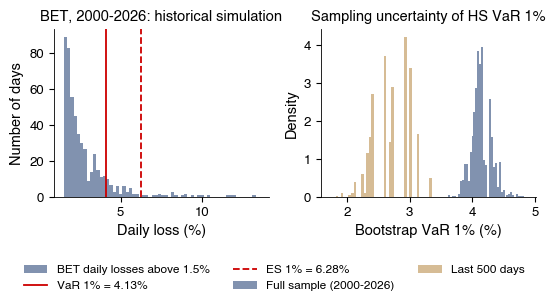

,full,w500
N,6670,500
start,2000-01-06,2024-09-12
var1,4.126959,2.711855
es1,6.278785,3.22082
var2_5,2.798908,2.054348
es2_5,4.569397,2.691839
ci_lo,3.847795,2.114385
ci_hi,4.456415,3.12267
n_beyond,67,5


In [18]:
# Solution
def b1_bet_hs():
    L = -100 * log_returns('bet')
    out = {}
    boots = {}
    for tag, x in [('full', L), ('w500', L.iloc[-500:])]:
        v1, e1 = hs_var_es(x, 0.01)
        v2, e2 = hs_var_es(x, 0.025)
        ci, bs = boot_ci(x.values, lambda y: hs_var_es(y, 0.01)[0])
        boots[tag] = bs
        out[tag] = dict(N=len(x), start=str(x.index[0].date()), var1=v1, es1=e1, var2_5=v2, es2_5=e2,
                        ci_lo=ci[0], ci_hi=ci[1], n_beyond=int((x >= v1).sum()))
    # chart: loss tail + bootstrap distributions
    _style()
    fig, axes = plt.subplots(1, 2, figsize=(W_FIG, 2.6))
    ax = axes[0]
    ax.hist(L[L > 1.5], bins=np.linspace(1.5, 13.5, 61), color=MainBlue, alpha=0.55, label='BET daily losses above 1.5%')
    ax.axvline(out['full']['var1'], color=IDAred, lw=1.3, label=f"VaR 1% = {out['full']['var1']:.2f}%")
    ax.axvline(out['full']['es1'], color=IDAred, ls='--', lw=1.3, label=f"ES 1% = {out['full']['es1']:.2f}%")
    ax.set_xlabel('Daily loss (%)')
    ax.set_ylabel('Number of days')
    ax.set_title('BET, 2000-2026: historical simulation')
    pass
    ax = axes[1]
    ax.hist(boots['full'], bins=40, density=True, color=MainBlue, alpha=0.55, label='Full sample (2000-2026)')
    ax.hist(boots['w500'], bins=40, density=True, color=Amber, alpha=0.55, label='Last 500 days')
    ax.set_xlabel('Bootstrap VaR 1% (%)')
    ax.set_ylabel('Density')
    ax.set_title('Sampling uncertainty of HS VaR 1%')
    bottom_legend(fig, ncol=3, fontsize=8.5)
    plt.tight_layout()
    save_fig('ch7_sem_bet_hs')
    return out


pd.DataFrame(b1_bet_hs()).round(3)

In [19]:
# B1 block-bootstrap interval and B1 Extended asymptotic (i.i.d., HAC) intervals for VaR 1%
pd.DataFrame({'full': SX['b1_full'], 'last 500': SX['b1_w500']}).round(3)

,full,last 500
var1,4.127,2.712
f,0.008,0.016
se,0.160,0.273
se_hac,0.225,0.266
lo,3.813,2.177
hi,4.441,3.246
lo_hac,3.686,2.190
hi_hac,4.568,3.234
blk_lo,3.609,2.023
blk_hi,4.801,3.032


### B4. A GPD tail for BET [Solved] — after the lecture

- Threshold leaving the largest 5% of losses above it; $\hat\xi$, $\hat\beta$ with standard errors; VaR and ES at 1%, 0.5%, 0.1%; stability across thresholds.
- Interpretation:
  - is the BET tail heavier than the Normal distribution?
  - how sure are we?

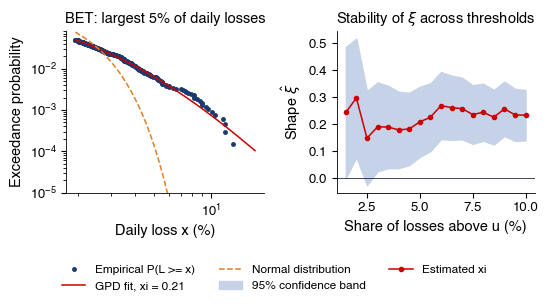

{'u': np.float64(1.9341864302995664),
 'xi': np.float64(0.20917979223399713),
 'beta': np.float64(1.1958177470341624),
 'nu': 334,
 'n': 6670,
 'se_xi': np.float64(0.06616337450274115),
 'se_beta': np.float64(0.10175416603506886),
 'evt_var1': np.float64(4.224892668482573),
 'evt_es1': np.float64(6.342930606256186),
 'hs_var1': np.float64(4.126958579751895),
 'hs_es1': np.float64(6.278784853593418),
 'n_beyond1': 67,
 'evt_var0_5': np.float64(5.474294112578411),
 'evt_es0_5': np.float64(7.922811130080035),
 'hs_var0_5': np.float64(5.378918259997512),
 'hs_es0_5': np.float64(7.855143286665594),
 'n_beyond0_5': 34,
 'evt_var0_1': np.float64(9.179474502863357),
 'evt_es0_1': np.float64(12.608048499964339),
 'hs_var0_1': np.float64(9.501589895769133),
 'hs_es0_1': np.float64(11.251818425971067),
 'n_beyond0_1': 7,
 'xi_range': [0.14851096707479988, 0.2976438909186965],
 'v0_1_range': [9.041439776125427, 9.51187997520639]}

In [20]:
# Solution
def b4_bet_gpd():
    L = (-100 * log_returns('bet')).values
    f = gpd_fit(L, 0.05)
    se_xi, se_beta = gpd_se(f)
    out = dict(u=f['u'], xi=f['xi'], beta=f['beta'], nu=f['nu'], n=f['n'], se_xi=se_xi, se_beta=se_beta)
    for a, tag in [(0.01, '1'), (0.005, '0_5'), (0.001, '0_1')]:
        v, e = gpd_var_es(f, a)
        hv, he = hs_var_es(L, a)
        out.update({f'evt_var{tag}': v, f'evt_es{tag}': e, f'hs_var{tag}': hv, f'hs_es{tag}': he,
                    f'n_beyond{tag}': int((L >= hv).sum())})
    # sensitivity to the threshold
    qs = np.linspace(0.10, 0.015, 18)          # share of losses above the threshold
    xis, lo, hi, v01 = [], [], [], []
    for q in qs:
        g = gpd_fit(L, q)
        s = gpd_se(g)[0]
        xis.append(g['xi'])
        lo.append(g['xi'] - 1.96 * s)
        hi.append(g['xi'] + 1.96 * s)
        v01.append(gpd_var_es(g, 0.001)[0])
    out['xi_range'] = [float(min(xis)), float(max(xis))]
    out['v0_1_range'] = [float(min(v01)), float(max(v01))]
    _style()
    fig, axes = plt.subplots(1, 2, figsize=(W_FIG, 2.6))
    ax = axes[0]
    xs = np.sort(L[L > f['u']])
    emp = (1 - np.arange(len(xs)) / len(xs)) * f['nu'] / f['n']
    ax.loglog(xs, emp, 'o', ms=2.5, color=MainBlue, label='Empirical P(L >= x)')
    xx = np.linspace(f['u'], xs[-1] * 1.3, 200)
    ax.loglog(xx, f['nu'] / f['n'] * stats.genpareto.sf(xx - f['u'], f['xi'], scale=f['beta']), color=IDAred,
              label=f"GPD fit, xi = {f['xi']:.2f}")
    ax.loglog(xx, stats.norm.sf(xx, L.mean(), L.std()), color=Orange, ls='--', label='Normal distribution')
    ax.set_ylim(1e-5, 0.08)
    ax.set_xlabel('Daily loss x (%)')
    ax.set_ylabel('Exceedance probability')
    ax.set_title('BET: largest 5% of daily losses')
    pass
    ax = axes[1]
    ax.fill_between(100 * qs, lo, hi, color=LightGray, label='95% confidence band')
    ax.plot(100 * qs, xis, 'o-', ms=3, color=IDAred, label='Estimated xi')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Share of losses above u (%)')
    ax.set_ylabel(r'Shape $\hat\xi$')
    ax.set_title(r'Stability of $\xi$ across thresholds')
    bottom_legend(fig, ncol=3, fontsize=8.5)
    plt.tight_layout()
    save_fig('ch7_sem_bet_gpd')
    return out


b2_bet_gpd()

In [21]:
# B4 Extended: extremal index and declustered GPD
print(extremal_index(loss['bet'].values, 0.05))
extremal_index(loss['bet'].values, 0.01)

{'u': np.float64(1.9341864302995664), 'N': 334, 'theta': np.float64(0.32078876105010007), 'n_clusters': 100, 'mean_size': 3.34, 'xi': np.float64(0.20917979223399713), 'se_xi': np.float64(0.06616337450274115), 'xi_c': np.float64(0.268679519873381), 'se_xi_c': np.float64(0.12686795198733808), 'beta_c': np.float64(1.4742231495306608), 'se_xi_eff': np.float64(0.11681754503612903)}


{'u': np.float64(4.126958579751895),
 'N': 67,
 'theta': np.float64(0.39791070574334986),
 'n_clusters': 27,
 'mean_size': 2.4814814814814814,
 'xi': np.float64(0.07321034769304616),
 'se_xi': np.float64(0.13111351185509657),
 'xi_c': np.float64(-0.34430900963060845),
 'se_xi_c': np.float64(0.12618778993166016),
 'beta_c': np.float64(4.181159464672045),
 'se_xi_eff': np.float64(0.20785220595817536)}

### B3. Tomorrow's filtered VaR for Bitcoin [Proposed]

- AR(1)-GARCH(1,1), filtered VaR and ES 1% for the next day vs historical simulation; exceedances in the last two years. Worked example to follow: B1.
- Interpretation:
  - why do the three VaRs differ?
  - which method misses more often?

In [ ]:
# Your code here


### B6. Cornish–Fisher vs empirical quantiles [Proposed]

- Five series; Normal, Cornish–Fisher and historical VaR at 1% and 2.5%, with a 95% bootstrap interval for the historical VaR 1%. Worked example to follow: A1, B1.
- Interpretation: why does Cornish–Fisher work better at 2.5% than at 1%?

In [ ]:
# Your code here


### B5. Risk contributions of a four-asset portfolio [Proposed] — after the lecture

- Equal weights in SPY, TLT, GLD, Bitcoin; Normal VaR 1% with Euler contributions and historical ES 2.5% contributions. Worked example to follow: A5.
- Interpretation: is equal money equal risk? (comparing Normal VaR 1% with historical ES 2.5% changes both the model and the level)

In [ ]:
# Your code here


### B2. How precise is an ES estimate? [Proposed]

- ES 2.5% of the S&P 500 and BET: i.i.d. and moving-block (20 days) bootstrap intervals. Worked example to follow: B1.
- Interpretation:
  - which samples meet the $\pm 0.3$ pp target?
  - what governs the width?

In [ ]:
# Your code here


### B7. CAViaR on BET [Proposed]

- Symmetric absolute value CAViaR at 1%, estimated on 2000–2015 by the pinball loss; out of sample 2016–2026 vs FHS and 500-day historical simulation; the COVID-19 window. Worked example to follow: B3.
- Interpretation: can the difference be attributed to the model class when CAViaR is fitted once and FHS every year?

In [ ]:
# Your code here


## Part C — AI critique and open projects

### C2. ES capital, BVB vs S&P 500 [Open]

- How much capital does an ES 2.5% require for 1 million invested in eight BVB blue chips (equal weights) versus SPY, over the last ten years?
- Simple returns, compounded 10-day losses, a stressed 250-day window (largest one-day ES 2.5%), liquidity horizons of 10 or 20 days, capital = 1.5 × stressed ES; block-bootstrap intervals with the stress window held fixed.

In [ ]:
# Your code here


### C1. Critique an AI answer [Proposed]

- Prompt given to the AI: *"`px` holds daily BET closes, 2000–2026. Give me the one-day historical VaR 1% and ES 2.5% as positive log losses in %, and the 10-day VaR 1%."*
- Answer: the code below (numbered lines 1–6), which runs without an error message:

```python
import numpy as np
r = 100 * np.log(px).diff().dropna()                 # daily log returns, %
loss = -r                                            # log loss, %
var1 = np.percentile(r, 99)                          # VaR 1%
es25 = loss[loss >= np.percentile(loss, 99)].mean()  # ES 2.5%
var10 = 10 * var1                                    # 10-day VaR 1%
```
- Conclusion of the AI: *"VaR 1% = 3.95%, ES 2.5% = 6.28%, 10-day VaR 1% = 39.46%."*
- Questions:
  - which lines of the AI answer are wrong?
  - what are the correct numbers?
- The answer contains **three** mistakes typical for VaR and ES; everything else is correct. Data: the BET data of B1.
- Tasks: (1) for each mistake, name the line number and explain in one sentence why it is wrong, using $VaR_\alpha = -q_\alpha(r) = q_{1-\alpha}(L)$; (2) say how you would detect it: a count of observations, a number from B1, or a slide of the lecture; (3) write the corrected lines, including the 10-day VaR from overlapping 10-day losses, and recompute the three numbers; (4) check the corrected ES 2.5%: how many losses does it average? How many should it average?
- Report: an error table (line, error, detection, correction) and the corrected numbers; log each error you actually found in `AI_ERRORS.md`.
- Interpretation: why does the code run without an error message although the answer is wrong?
- Worked example to follow: B1.

In [ ]:
# C1: your corrected code


### C3. Deep quantile regression for VaR [Open]

- Question: does a small neural network beat linear quantile regression for the S&P 500 VaR 1%, as in the lecture case study (Chronopoulos, Raftapostolos and Kapetanios, 2024)?
- Data: S&P 500 daily closes up to 31 August 2020 (the paper starts in 1985); unscaled daily log returns $r_t$; tuning on all but the last 2,000 days, evaluation on the last 2,000 days; one predictor set: GARCH(1,1) $\sigma_t$ estimated on the tuning sample only; $\alpha = 1\%$.
- Tasks: (1) build training pairs $(x_t, r_{t+10})$ whose targets all lie in the tuning sample; (2) fit a linear quantile regression and one network (one hidden ReLU layer of 5 units, ridge penalty 0.01, Adam optimiser, i.e. stochastic gradient descent with adaptive step sizes, early stopping) by the pinball loss, standardising the predictors on the training part of each cross-validation split only; (3) compare mean pinball losses on the evaluation sample with a Diebold–Mariano test (HAC, 10 lags), over 5 random seeds.
- Report: a table of mean pinball losses, DM statistics and exceedance counts, per seed.
- Extensions (optional): the four predictor sets of the paper; rolling re-estimation on September 2020–2026 for the S&P 500 and the BET; joint (VaR, ES) outputs trained on the FZ0 loss.
- Interpretation (one page): can a gain be attributed to non-linearity when architecture, penalty and tuning change together?

In [ ]:
# C3: your code
